In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("House_price.csv")

In [35]:
df.head(6)

,Unnamed: 0,beds,baths,size,zip_code,price
0,0,3,2.5,2590.0,98144,795000.0
1,1,4,2.0,2240.0,98106,915000.0
2,2,4,3.0,2040.0,98107,950000.0
3,3,4,3.0,3800.0,98199,1950000.0
4,4,2,2.0,1042.0,98102,950000.0
5,5,2,2.0,1190.0,98107,740000.0


In [36]:
df.shape

(2016, 6)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2016 entries, 0 to 2015
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2016 non-null   int64  
 1   beds        2016 non-null   int64  
 2   baths       2016 non-null   float64
 3   size        2016 non-null   float64
 4   zip_code    2016 non-null   int64  
 5   price       2016 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 94.6 KB


In [38]:

df.isnull().sum()

Unnamed: 0    0
beds          0
baths         0
size          0
zip_code      0
price         0
dtype: int64

In [39]:
df.dropna(inplace=True)
df.isnull().sum().sum() # Should be 0 now

np.int64(0)

In [40]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    print("Dropped 'Unnamed: 0' column.")
else:
    print("Column already removed.")

Dropped 'Unnamed: 0' column.


In [41]:
df['zip_code'] = df['zip_code'].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2016 entries, 0 to 2015
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   beds      2016 non-null   int64  
 1   baths     2016 non-null   float64
 2   size      2016 non-null   float64
 3   zip_code  2016 non-null   object 
 4   price     2016 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 78.9+ KB


In [42]:
df['price_per_sqft'] = df['price'] / df['size']
df.head()

,beds,baths,size,zip_code,price,price_per_sqft
0,3,2.5,2590.0,98144,795000.0,306.949807
1,4,2.0,2240.0,98106,915000.0,408.482143
2,4,3.0,2040.0,98107,950000.0,465.686275
3,4,3.0,3800.0,98199,1950000.0,513.157895
4,2,2.0,1042.0,98102,950000.0,911.708253


In [43]:
df['zip_code'].value_counts()

zip_code
98115    170
98103    166
98117    151
98144    113
98122    109
98118    100
98116     88
98107     83
98126     80
98106     78
98125     78
98105     73
98199     72
98119     70
98133     61
98109     61
98136     60
98102     60
98121     59
98112     57
98178     44
98168     44
98146     41
98108     33
98177     27
98101     23
98104     14
98164      1
Name: count, dtype: int64

In [44]:

print("Unique Bathrooms:", sorted(df['baths'].unique()))

Unique Bathrooms: [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0), np.float64(5.5), np.float64(6.0), np.float64(6.5), np.float64(7.0), np.float64(8.5), np.float64(9.0)]


In [18]:

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6) 

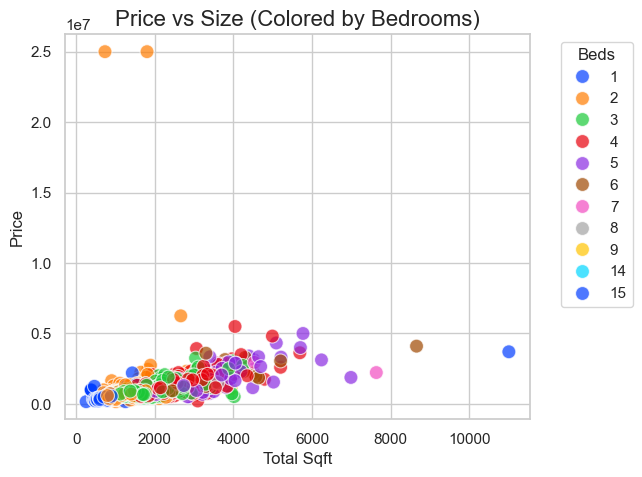

In [21]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='size', y='price', data=df, hue='beds', palette='bright', s=100, alpha=0.7)

plt.title("Price vs Size (Colored by Bedrooms)", fontsize=16)
plt.xlabel("Total Sqft", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend(title='Beds', bbox_to_anchor=(1.05, 1), loc='upper left') # Legend bahar shift kiya
plt.show()

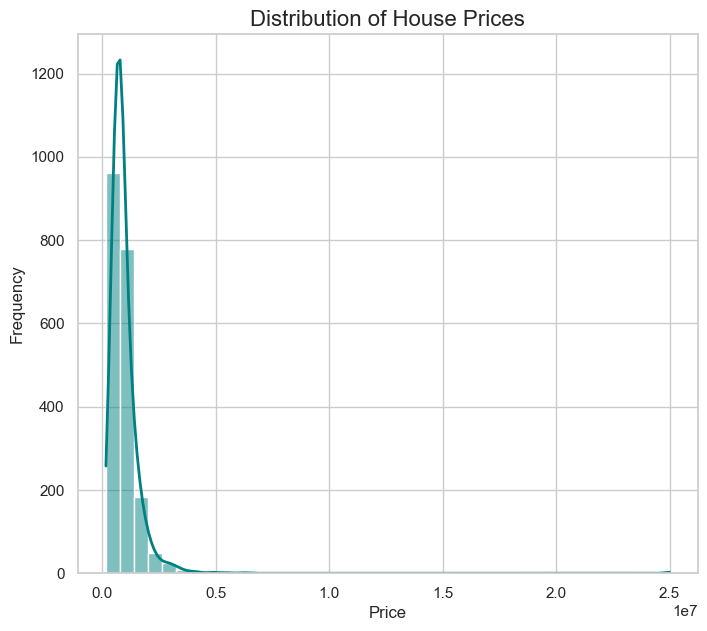

In [23]:
plt.figure(figsize=(8, 7))
sns.histplot(df['price'], kde=True, color='teal', bins=40, line_kws={'linewidth': 2})

plt.title("Distribution of House Prices", fontsize=16)
plt.xlabel("Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

C:\Users\samee\AppData\Local\Temp\ipykernel_19632\2416135809.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='beds', y='price', data=df, palette='coolwarm')


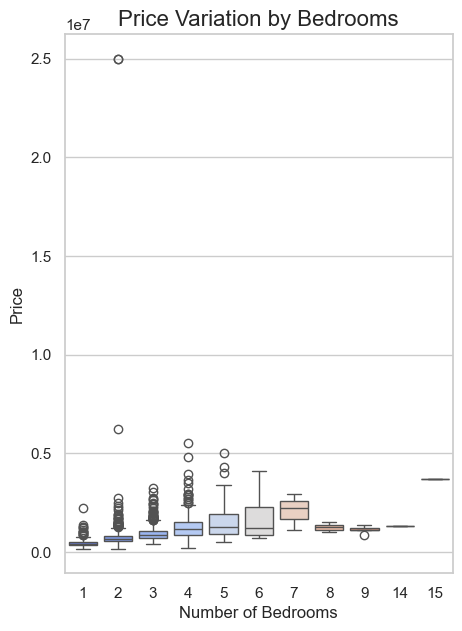

In [24]:
plt.figure(figsize=(5, 7))
sns.boxplot(x='beds', y='price', data=df, palette='coolwarm')

plt.title("Price Variation by Bedrooms", fontsize=16)
plt.xlabel("Number of Bedrooms", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

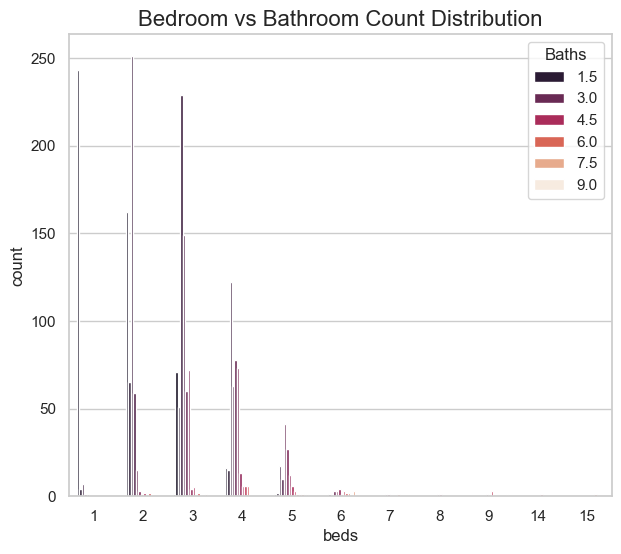

In [25]:
plt.figure(figsize=(7, 6))
sns.countplot(x='beds', hue='baths', data=df, palette='rocket')

plt.title("Bedroom vs Bathroom Count Distribution", fontsize=16)
plt.legend(title='Baths', loc='upper right')
plt.show()

In [26]:
# Filtering data
df_clean = df[~(df['size'] / df['beds'] < 300)]
print(f"Original shape: {df.shape}")
print(f"Shape after Bedroom logic cleaning: {df_clean.shape}")

Original shape: (2016, 6)
Shape after Bedroom logic cleaning: (2002, 6)


In [27]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('zip_code'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        # Keep data within 1 Standard Deviation
        reduced_df = subdf[(subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df_clean = remove_pps_outliers(df_clean)
print("Shape after PPS outlier removal:", df_clean.shape)

Shape after PPS outlier removal: (1502, 6)


In [28]:
# Removing rows where baths > beds + 2
df_clean = df_clean[df_clean['baths'] < df_clean['beds'] + 2]
print("Final Shape:", df_clean.shape)

Final Shape: (1494, 6)


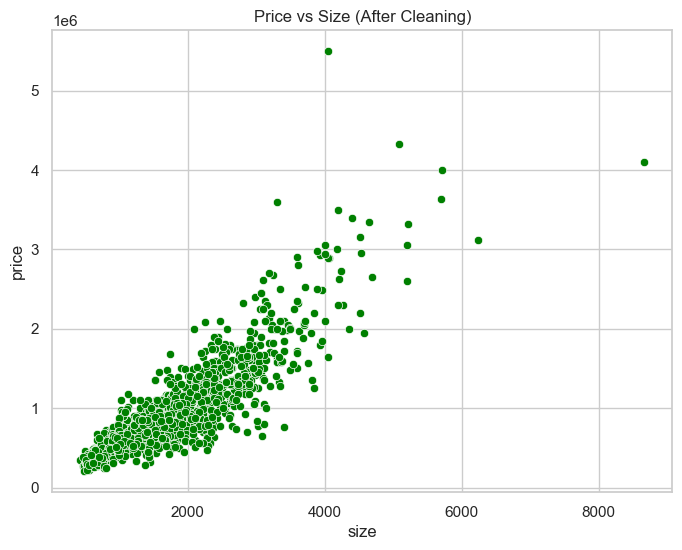

In [29]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='size', y='price', data=df_clean, color='green')
plt.title("Price vs Size (After Cleaning)")
plt.show()

In [64]:
X = df_clean.drop(columns=['price', 'price_per_sqft'])
y = df_clean['price']

In [65]:
X.head()

,beds,baths,size,zip_code
0,1,1.0,792.0,98101
1,1,1.0,474.0,98101
2,1,1.0,783.0,98101
3,1,1.0,808.0,98101
4,1,1.0,700.0,98101


In [66]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (1195, 4)
Testing Data Shape: (299, 4)


In [68]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

column_trans = make_column_transformer(
    (OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['zip_code']),
    remainder='passthrough'
)

scaler = StandardScaler()

lr = LinearRegression()

pipe = make_pipeline(column_trans, scaler, lr)

pipe.fit(X_train, y_train)
print("Training Completed.")

y_pred = pipe.predict(X_test)